# MBA03 · Week 3 — Studying a function, and adding one up
**European School of Economics · Thu 8 Oct 2026 · Tutor: Niccolò Salvini**

Today is the mathematical content of the midterm: the seven-step study, optimisation, and integration.

In [1]:
# Setup (Colab has numpy, matplotlib, plotly and sympy preinstalled; this is a no-op there)
import subprocess, sys
try:
    import plotly, sympy, matplotlib
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "plotly", "sympy", "matplotlib"])
import numpy as np, plotly.graph_objects as go, sympy as sp
import matplotlib.pyplot as plt
q = sp.Symbol("q", positive=True)
print("ready")

ready


## A. The seven steps, done by machine so you can check yourself

Do it on paper first. This cell is the answer key, not the method.

In [2]:
def study(f, name="f"):
    fp, fpp = sp.diff(f, q), sp.diff(f, q, 2)
    print(f"{name}(q) = {f}")
    print("  1 domain     :", sp.calculus.util.continuous_domain(f, q, sp.Interval(0, sp.oo)))
    print("  2 zeros      :", [round(float(r), 3) for r in sp.solve(f, q) if r.is_real])
    print(f"  3 f'         : {fp}")
    stat = sp.solve(fp, q)
    print("  4 stationary :", stat)
    for s in stat:
        kind = "maximum" if fpp.subs(q, s) < 0 else ("minimum" if fpp.subs(q, s) > 0 else "unclear")
        print(f"  5 at q={float(s):.3f}: f''={float(fpp.subs(q, s)):.3f} → {kind}, f={float(f.subs(q, s)):,.2f}")
    print("  6 f''        :", fpp, "  inflection at:", sp.solve(fpp, q))
    print("  7 as q→∞     :", sp.limit(f, q, sp.oo))

study(-4*q**2 + 1200*q - 60000, "π")

π(q) = -4*q**2 + 1200*q - 60000
  1 domain     : Interval(0, oo)
  2 zeros      : [63.397, 236.603]
  3 f'         : 1200 - 8*q
  4 stationary : [150]
  5 at q=150.000: f''=-8.000 → maximum, f=30,000.00
  6 f''        : -8   inflection at: []
  7 as q→∞     : -oo


## B. Average cost meets marginal cost

Where does the average stop falling? Move the slider and watch the two curves.

In [3]:
C  = lambda x: 0.4*x**2 + 3*x + 25
AC = lambda x: C(x)/x
MC = lambda x: 0.8*x + 3
xs = np.linspace(1.5, 18, 300)

fig = go.Figure([
    go.Scatter(x=xs, y=AC(xs), name="average cost C(q)/q", line=dict(color="#363636", width=3)),
    go.Scatter(x=xs, y=MC(xs), name="marginal cost C'(q)", line=dict(color="#AF1F25", width=3)),
])
qstar = float(np.sqrt(62.5))
fig.add_scatter(x=[qstar], y=[AC(qstar)], mode="markers+text", marker=dict(size=13, color="#CDBA80"),
                text=[f"q* = {qstar:.2f}"], textposition="top right", showlegend=False)
fig.update_layout(template="simple_white", height=460, xaxis_title="q",
                  yaxis_title="€ thousand per unit", yaxis_range=[0, 20])
fig.show()

In [4]:
Cs = sp.Rational(4,10)*q**2 + 3*q + 25
ACs = sp.simplify(Cs/q)
qm = [s for s in sp.solve(sp.diff(ACs, q), q) if s.is_real and s > 0][0]
print(f"AC is lowest at q = {float(qm):.4f}")
print(f"  AC there = {float(ACs.subs(q, qm)):.4f}")
print(f"  MC there = {float(sp.diff(Cs, q).subs(q, qm)):.4f}   ← equal, and not by accident")

AC is lowest at q = 7.9057
  AC there = 9.3246
  MC there = 9.3246   ← equal, and not by accident


## C. Optimisation — marginal revenue equals marginal cost

A firm with log revenue. Change the 30 and watch the optimum move.

In [5]:
for a in (20, 30, 40, 60):
    pi = a*sp.log(q + 1) - Cs
    root = [r for r in sp.solve(sp.Eq(sp.diff(pi, q), 0), q) if r.is_real and r > 0]
    if root:
        qs_ = float(root[0])
        print(f"R = {a} ln(q+1):  q* = {qs_:6.3f},  π(q*) = {float(pi.subs(q, root[0])):>8,.2f}k")

R = 20 ln(q+1):  q* =  2.811,  π(q*) =    -9.84k
R = 30 ln(q+1):  q* =  3.901,  π(q*) =     4.89k
R = 40 ln(q+1):  q* =  4.829,  π(q*) =    21.70k
R = 60 ln(q+1):  q* =  6.394,  π(q*) =    59.50k


### 🔍 CHECK
One of those rows has a positive optimum and a **negative** profit. Find it, and say what a manager should do in that case. Maximising profit and making a profit are not the same thing.

## D. Integration — thinner slices, truer area

`MC(q) = 0.8q + 3`. What do the first twenty bikes cost in total?

In [6]:
mc = lambda x: 0.8*x + 3
exact = 0.4*20**2 + 3*20
for n in (4, 8, 20, 60, 500):
    dx = 20/n
    left = sum(mc(i*dx)*dx for i in range(n))
    print(f"n = {n:>3}  left-endpoint sum = {left:7.2f}   (exact {exact})")

n =   4  left-endpoint sum =  180.00   (exact 220.0)
n =   8  left-endpoint sum =  200.00   (exact 220.0)
n =  20  left-endpoint sum =  212.00   (exact 220.0)
n =  60  left-endpoint sum =  217.33   (exact 220.0)
n = 500  left-endpoint sum =  219.68   (exact 220.0)


In [7]:
print("∫ (q⁵ − 3q³ + 2)/q² dq =", sp.integrate((q**5 - 3*q**3 + 2)/q**2, q), "+ c")
print("∫₀²⁰ (0.8q + 3) dq     =", sp.integrate(sp.Rational(8,10)*q + 3, (q, 0, 20)))
print()
pi = -4*q**2 + 1200*q - 60000
print("∫₁₀₀¹⁵⁰ π'(q) dq =", sp.integrate(sp.diff(pi, q), (q, 100, 150)))
print("π(150) − π(100)  =", pi.subs(q, 150) - pi.subs(q, 100), " ← the same number")

∫ (q⁵ − 3q³ + 2)/q² dq = q**4/4 - 3*q**2/2 - 2/q + c
∫₀²⁰ (0.8q + 3) dq     = 220

∫₁₀₀¹⁵⁰ π'(q) dq = 10000
π(150) − π(100)  = 10000  ← the same number


**The integral of the marginal is the change in the total.** That sentence is the whole of integration.

## Drills, solved in code

This section is an optional companion: the code is **not examined**, the exam is on paper. Every drill in `drills.md` is solved here, one cell per question, with `sympy` doing the algebra you would do by hand. Do the drill on paper first, then run the cell and compare.

In [8]:
# Symbols used in every drill below (real numbers, as on paper)
q, x, c = sp.symbols('q x c', real=True)

def sketch(f, var, a, b, title, points=(), asymptote=None):
    # draw f between a and b, mark the (value, label) points, dash a vertical asymptote
    xs = np.linspace(a, b, 400)
    plt.figure(figsize=(6, 3.5))
    plt.plot(xs, sp.lambdify(var, f, "numpy")(xs), color="#AF1F25", lw=2.5)
    plt.axhline(0, color="grey", lw=0.8)
    if asymptote is not None:
        plt.axvline(asymptote, color="#363636", ls="--", lw=1)
    for px, label in points:
        py = float(f.subs(var, px))
        plt.plot(px, py, "o", color="#363636")
        plt.annotate(label, (px, py), textcoords="offset points", xytext=(6, 6))
    plt.title(title); plt.xlabel(str(var)); plt.show()

print("symbols and sketch() ready")

symbols and sketch() ready


### D1 — the full study of a profit function
Study $\pi(q) = -4q^2 + 1200q - 60{,}000$ completely: domain, zeros, sign, $\pi'$ and the stationary point, $\pi''$ and its nature, behaviour as $q \to \infty$, and a labelled sketch.

zeros: [150 - 50*sqrt(3), 50*sqrt(3) + 150] ≈ [63.4, 236.6]
sign at q = 150: 1   sign at q = 0: -1
π'(q) = 1200 - 8*q = 0 at q = 150;   π''(q) = -8 < 0 → maximum
6 behaviour: as q → ∞, π → -oo
Answer: π > 0 between q ≈ 63.4 and 236.6; maximum at q = 150 with π = €30,000; π(0) = −€60,000.


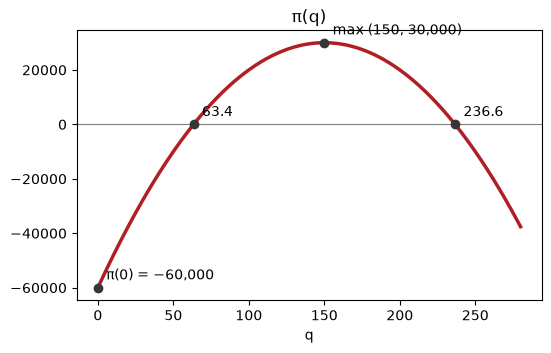

In [9]:
pi = -4*q**2 + 1200*q - 60000
# 1 domain: a polynomial, every real q (for a quantity, q >= 0)
zeros = sorted(sp.solve(pi, q))                        # 2 zeros
print("zeros:", zeros, "≈", [round(float(z), 1) for z in zeros])
# 3 sign: a = -4 < 0, so positive between the zeros; test one point inside, one outside
print("sign at q = 150:", sp.sign(pi.subs(q, 150)), "  sign at q = 0:", sp.sign(pi.subs(q, 0)))
d1 = sp.diff(pi, q)                                    # 4 stationary point
q_star = sp.solve(d1, q)[0]
d2 = sp.diff(pi, q, 2)                                 # 5 nature
print(f"π'(q) = {d1} = 0 at q = {q_star};   π''(q) = {d2} < 0 → maximum")
top = int(pi.subs(q, q_star))
print("6 behaviour: as q → ∞, π →", sp.limit(pi, q, sp.oo))
assert [round(float(z), 1) for z in zeros] == [63.4, 236.6] and q_star == 150 and top == 30000
print(f"Answer: π > 0 between q ≈ 63.4 and 236.6; maximum at q = {q_star} with π = €{top:,}; π(0) = −€60,000.")
sketch(pi, q, 0, 280, "π(q)", [(0, "π(0) = −60,000"), (zeros[0], "63.4"), (zeros[1], "236.6"), (150, "max (150, 30,000)")])

### D2 (a) — domain and $C(0)$
$C(q) = 0.4q^2 + 3q + 25$ (€ thousand), $q \ge 0$. Domain, and $C(0)$. What is $C(0)$ called?

In [10]:
C = sp.Rational(2, 5)*q**2 + 3*q + 25       # 0.4 written as 2/5 so sympy stays exact
# a polynomial is defined everywhere; a quantity cannot be negative → [0, +∞)
fixed = C.subs(q, 0)
assert fixed == 25
print(f"Answer: domain [0, +∞); C(0) = {fixed}, the fixed cost: what the firm pays having produced nothing.")

Answer: domain [0, +∞); C(0) = 25, the fixed cost: what the firm pays having produced nothing.


### D2 (b) — average cost and its limits
$AC(q) = C(q)/q$. Find its domain, $\lim_{q\to 0^+} AC(q)$ and $\lim_{q\to\infty} AC(q)$.

In [11]:
AC = sp.expand(C / q)
dom = sp.calculus.util.continuous_domain(AC, q, sp.Interval(0, sp.oo))
lim0 = sp.limit(AC, q, 0, '+')        # fixed cost spread over almost nothing
limoo = sp.limit(AC, q, sp.oo)        # the 0.4q term takes over
print("AC(q) =", AC, "   domain:", dom)
assert dom == sp.Interval.open(0, sp.oo) and lim0 == sp.oo and limoo == sp.oo
print(f"Answer: domain (0, +∞); AC → {lim0} as q → 0⁺ and AC → {limoo} as q → ∞, so AC falls then rises.")

AC(q) = 2*q/5 + 3 + 25/q    domain: Interval.open(0, oo)
Answer: domain (0, +∞); AC → oo as q → 0⁺ and AC → oo as q → ∞, so AC falls then rises.


### D2 (c) — minimise average cost
Minimise $AC(q)$. At that quantity compute $AC$ and $C'(q)$, and comment.

In [12]:
dAC = sp.diff(AC, q)                                   # 2/5 − 25/q²
q_min = [s for s in sp.solve(dAC, q) if s > 0][0]      # keep the positive root
print("AC'(q) =", dAC, "= 0 at q =", q_min, "≈", round(float(q_min), 2))
print("AC''(q_min) =", sp.diff(AC, q, 2).subs(q, q_min), "> 0 → minimum")
ac_min = float(AC.subs(q, q_min))
mc_min = float(sp.diff(C, q).subs(q, q_min))
assert round(float(q_min), 2) == 7.91 and round(ac_min, 2) == 9.32 and round(mc_min, 2) == 9.32
print(f"Answer: AC is lowest at q ≈ {float(q_min):.2f}, where AC = {ac_min:.2f} and C' = {mc_min:.2f}: they are equal.")

AC'(q) = 2/5 - 25/q**2 = 0 at q = 5*sqrt(10)/2 ≈ 7.91
AC''(q_min) = 4*sqrt(10)/125 > 0 → minimum
Answer: AC is lowest at q ≈ 7.91, where AC = 9.32 and C' = 9.32: they are equal.


### D2b (a) — domain
$f(x) = x^2 - 3x + 7\ln(x+3)$. State the domain as an interval.

In [13]:
f = x**2 - 3*x + 7*sp.log(x + 3)
# the log needs x + 3 > 0
dom = sp.solve_univariate_inequality(x + 3 > 0, x, relational=False)
assert dom == sp.Interval.open(-3, sp.oo)
print("Answer: the domain is", dom, " i.e. (−3, +∞), open because ln 0 is undefined.")

Answer: the domain is Interval.open(-3, oo)  i.e. (−3, +∞), open because ln 0 is undefined.


### D2b (b) — the left end
Evaluate $\lim_{x\to -3^+} f(x)$ and say what it tells you about the graph.

In [14]:
print("x² − 3x at x = −3:", (x**2 - 3*x).subs(x, -3), "   ln(x + 3) → −∞")
left = sp.limit(f, x, -3, '+')
assert left == -sp.oo
print(f"Answer: f → {left} as x → −3⁺, so x = −3 is a vertical asymptote: the curve plunges down it.")

x² − 3x at x = −3: 18    ln(x + 3) → −∞
Answer: f → -oo as x → −3⁺, so x = −3 is a vertical asymptote: the curve plunges down it.


### D2b (c) — the right end
Evaluate $\lim_{x\to +\infty} f(x)$.

In [15]:
right = sp.limit(f, x, sp.oo)      # x² dominates the log
assert right == sp.oo
print(f"Answer: f → {right} as x → +∞; the x² term wins.")

Answer: f → oo as x → +∞; the x² term wins.


### D2b (d) — sketch
Sketch the shape, marking the asymptote.

f'(x) = (x + 2)*(2*x - 1)/(x + 3)   → turning points at [-2, 1/2]
  x = -2: f = 10.00, f'' = -5.00
  x = 1/2: f = 7.52, f'' = 1.43
Answer: up from −∞ along x = −3, a local max at x = −2, a local min at x = ½, then up to +∞.


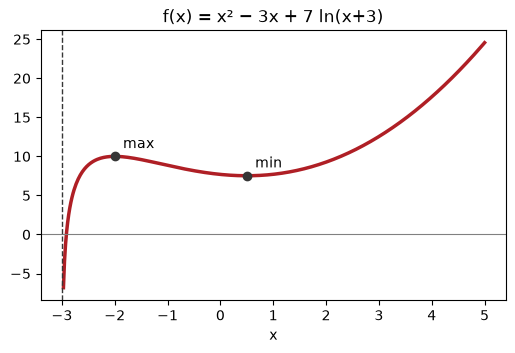

In [16]:
# Not asked, but it helps the sketch: where does the curve turn?
df = sp.factor(sp.together(sp.diff(f, x)))
turns = sp.solve(df, x)
print("f'(x) =", df, "  → turning points at", turns)
for t in turns:
    print(f"  x = {t}: f = {float(f.subs(x, t)):.2f}, f'' = {float(sp.diff(f, x, 2).subs(x, t)):.2f}")
print("Answer: up from −∞ along x = −3, a local max at x = −2, a local min at x = ½, then up to +∞.")
sketch(f, x, -2.97, 5, "f(x) = x² − 3x + 7 ln(x+3)", [(-2, "max"), (sp.Rational(1, 2), "min")], asymptote=-3)

### D3 (a) — stationary points
$f(q) = q^3 - 12q^2 + 36q$ on $[0, 10]$. Stationary points and their nature.

In [17]:
g = q**3 - 12*q**2 + 36*q
dg = sp.diff(g, q)
print("f'(q) =", dg, "=", sp.factor(dg))
d2g = sp.diff(g, q, 2)
for s in sp.solve(dg, q):
    kind = "maximum" if d2g.subs(q, s) < 0 else "minimum"
    print(f"  q = {s}: f'' = {d2g.subs(q, s)} → {kind}, f = {g.subs(q, s)}")
assert sp.solve(dg, q) == [2, 6] and g.subs(q, 2) == 32 and g.subs(q, 6) == 0
print("Answer: maximum at (2, 32), minimum at (6, 0).")

f'(q) = 3*q**2 - 24*q + 36 = 3*(q - 6)*(q - 2)
  q = 2: f'' = -12 → maximum, f = 32
  q = 6: f'' = 12 → minimum, f = 0
Answer: maximum at (2, 32), minimum at (6, 0).


### D3 (b) — inflection point

In [18]:
infl = sp.solve(d2g, q)[0]
print("f''(q) =", d2g, "= 0 at q =", infl)
print("f'' at 3 and at 5:", d2g.subs(q, 3), d2g.subs(q, 5), "→ the sign changes, so it is an inflection")
assert infl == 4 and g.subs(q, 4) == 16
print(f"Answer: inflection at ({infl}, {g.subs(q, infl)}).")

f''(q) = 6*(q - 4) = 0 at q = 4
f'' at 3 and at 5: -6 6 → the sign changes, so it is an inflection
Answer: inflection at (4, 16).


### D3 (c) — sketch

Answer: rises to (2, 32), falls to (6, 0), rises again to (10, 160).


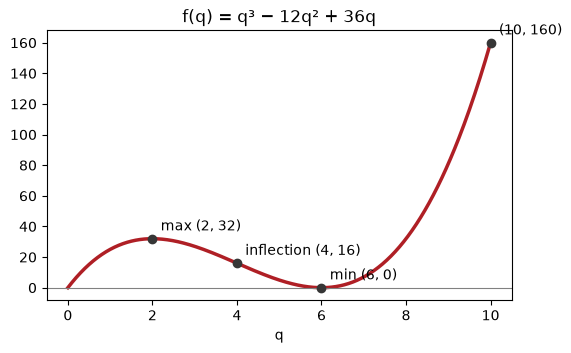

In [19]:
assert g.subs(q, 10) == 160
print("Answer: rises to (2, 32), falls to (6, 0), rises again to (10, 160).")
sketch(g, q, 0, 10, "f(q) = q³ − 12q² + 36q", [(2, "max (2, 32)"), (4, "inflection (4, 16)"), (6, "min (6, 0)"), (10, "(10, 160)")])

### D4 (a) — profit
$R(q) = 30\ln(q+1)$, $C(q) = 0.4q^2 + 3q + 25$ (€ thousand), $q \ge 0$. Write $\pi(q)$.

In [20]:
R = 30*sp.log(q + 1)
profit = R - C
print("Answer: π(q) =", profit)
assert sp.simplify(profit - (30*sp.log(q + 1) - sp.Rational(2, 5)*q**2 - 3*q - 25)) == 0

Answer: π(q) = -2*q**2/5 - 3*q + 30*log(q + 1) - 25


### D4 (b) — marginal profit
Write $\pi'(q)$.

In [21]:
dprofit = sp.diff(profit, q)
print("Answer: π'(q) =", dprofit)
assert sp.simplify(dprofit - (30/(q + 1) - sp.Rational(4, 5)*q - 3)) == 0

Answer: π'(q) = -4*q/5 - 3 + 30/(q + 1)


### D4 (c) — solve $\pi'(q) = 0$
Leave it as an equation in $q$ first, then solve the quadratic it becomes.

In [22]:
print("Equation: 30/(q + 1) = 0.8q + 3")
# multiply both sides by (q + 1), bring everything to one side, then multiply by 5
quadratic = sp.expand(5*((sp.Rational(4, 5)*q + 3)*(q + 1) - 30))
print("Quadratic:", quadratic, "= 0")
delta = 19**2 - 4*4*(-135)
roots = sp.solve(quadratic, q)
print("Δ =", delta, "  roots ≈", [round(float(r), 2) for r in roots])
q_opt = [r for r in roots if r > 0][0]           # a quantity cannot be negative
assert quadratic == 4*q**2 + 19*q - 135 and delta == 2521 and round(float(q_opt), 2) == 3.90
print(f"Answer: q ≈ {float(q_opt):.2f} (the negative root is discarded).")

Equation: 30/(q + 1) = 0.8q + 3
Quadratic: 4*q**2 + 19*q - 135 = 0
Δ = 2521   roots ≈ [3.9, -8.65]
Answer: q ≈ 3.90 (the negative root is discarded).


### D4 (d) — is it a maximum?
Confirm with $\pi''$.

In [23]:
d2profit = sp.diff(profit, q, 2)
print("π''(q) =", d2profit, "  (both terms negative for every q ≥ 0)")
value = float(d2profit.subs(q, q_opt))
assert value < 0
print(f"Answer: π''({float(q_opt):.2f}) = {value:.2f} < 0, so it is a maximum.")

π''(q) = -2*(2/5 + 15/(q + 1)**2)   (both terms negative for every q ≥ 0)
Answer: π''(3.90) = -2.05 < 0, so it is a maximum.


### D4 (e) — profitable?
Is the firm profitable at that quantity? Answer with a number.

In [24]:
best = float(profit.subs(q, q_opt))
print(f"30 ln(q+1) = {float(R.subs(q, q_opt)):.2f},  C(q) = {float(C.subs(q, q_opt)):.2f}")
assert round(best, 2) == 4.89
print(f"Answer: π({float(q_opt):.2f}) ≈ €{best:.2f}k > 0: profitable, but only just.")

30 ln(q+1) = 47.68,  C(q) = 42.79
Answer: π(3.90) ≈ €4.89k > 0: profitable, but only just.


### D5 (a) — the condition in words
For the firm in D4, write $\pi'(q) = 0$ as $R'(q) = C'(q)$, in words.

In [25]:
MR = sp.diff(R, q)          # marginal revenue
MC = sp.diff(C, q)          # marginal cost
print("R'(q) =", MR, "   C'(q) =", MC)
assert sp.simplify(MR - MC - dprofit) == 0     # π' is exactly R' − C'
print("Answer: π' = R' − C' = 0 means R'(q) = C'(q): produce up to where one more unit brings in what it costs.")

R'(q) = 30/(q + 1)    C'(q) = 4*q/5 + 3
Answer: π' = R' − C' = 0 means R'(q) = C'(q): produce up to where one more unit brings in what it costs.


### D5 (b) — at $q = 2$
Compute $R'(2)$ and $C'(2)$. Which is larger, and what should the firm do?

In [26]:
mr2, mc2 = MR.subs(q, 2), MC.subs(q, 2)
print(f"R'(2) = {mr2},  C'(2) = {float(mc2)}")
assert mr2 == 10 and mc2 == sp.Rational(23, 5)
print(f"Answer: MR ({mr2}) > MC ({float(mc2)}): each extra unit still adds {float(mr2 - mc2)}, so produce more, up to q ≈ 3.90.")

R'(2) = 10,  C'(2) = 4.6
Answer: MR (10) > MC (4.6): each extra unit still adds 5.4, so produce more, up to q ≈ 3.90.


### D6 — the box
A box with a square base and no lid must hold 32 m³. Minimise the material: $S = x^2 + 4xh$, with $x^2 h = 32$.

In [27]:
side = sp.Symbol('x', positive=True)       # a length, so positive
h = 32 / side**2                           # from the volume constraint
S = side**2 + 4*side*h
print("S(x) =", sp.simplify(S))
x_best = sp.solve(sp.diff(S, side), side)[0]
print("S'(x) = 0 at x =", x_best, "  S''(x) =", sp.diff(S, side, 2).subs(side, x_best), "> 0 → minimum")
assert x_best == 4 and h.subs(side, 4) == 2 and S.subs(side, 4) == 48
print(f"Answer: base {x_best} m × {x_best} m, height {h.subs(side, x_best)} m, surface {S.subs(side, x_best)} m².")

S(x) = (x**3 + 128)/x
S'(x) = 0 at x = 4   S''(x) = 6 > 0 → minimum
Answer: base 4 m × 4 m, height 2 m, surface 48 m².


### D7 (a)
$\displaystyle\int \frac{q^5 - 3q^3 + 2}{q^2}\,dq$, splitting term by term.

In [28]:
split = sp.expand((q**5 - 3*q**3 + 2) / q**2)        # divide each term by q² first
print("split:", split)
F = sp.integrate(split, q)                            # then each term is a power
assert sp.simplify(F - (q**4/4 - sp.Rational(3, 2)*q**2 - 2/q)) == 0
print("Answer:", F, "+ c")

split: q**3 - 3*q + 2/q**2
Answer: q**4/4 - 3*q**2/2 - 2/q + c


### D7 (b)
$\displaystyle\int (4q^3 - 6q + 5)\,dq$

In [29]:
F = sp.integrate(4*q**3 - 6*q + 5, q)
assert F == q**4 - 3*q**2 + 5*q
print("Answer:", F, "+ c")

Answer: q**4 - 3*q**2 + 5*q + c


### D7 (c)
$\displaystyle\int \left(\frac{2}{q} + 3\sqrt{q}\right)dq$

In [30]:
log_part = sp.integrate(2/q, q)            # 2 ln|q| (sympy writes log without the modulus)
power_part = sp.integrate(3*sp.sqrt(q), q) # 3 · (2/3) q^(3/2)
print("∫ 2/q dq =", log_part, "   ∫ 3√q dq =", power_part)
assert sp.simplify(log_part - 2*sp.log(q)) == 0 and sp.simplify(power_part - 2*q**sp.Rational(3, 2)) == 0
print("Answer: 2 ln|q| + 2 q^(3/2) + c")

∫ 2/q dq = 2*log(q)    ∫ 3√q dq = 2*q**(3/2)
Answer: 2 ln|q| + 2 q^(3/2) + c


### D8 — find $f$ from $f'$
$f'(q) = 12q^2 - 6q + 1$ and $f(2) = 20$.

In [31]:
F = sp.integrate(12*q**2 - 6*q + 1, q) + c      # antiderivative with its constant
c_value = sp.solve(sp.Eq(F.subs(q, 2), 20), c)[0]
print("f(2) =", F.subs(q, 2), "= 20  →  c =", c_value)
answer = F.subs(c, c_value)
assert c_value == -2 and answer == 4*q**3 - 3*q**2 + q - 2
print("Answer: f(q) =", answer)

f(2) = c + 22 = 20  →  c = -2
Answer: f(q) = 4*q**3 - 3*q**2 + q - 2


### D8b — watch every sign
$f'(x) = 12x^2 - 4x$ and $f(-3) = 17$.

In [32]:
F = sp.integrate(12*x**2 - 4*x, x) + c
print("(−3)³ =", (-3)**3, "  (−3)² =", (-3)**2, "  ← the two traps")
c_value = sp.solve(sp.Eq(F.subs(x, -3), 17), c)[0]
print("f(−3) =", F.subs(x, -3), "= 17  →  c =", c_value)
answer = F.subs(c, c_value)
assert c_value == 143 and answer == 4*x**3 - 2*x**2 + 143
print("Answer: f(x) =", answer)

(−3)³ = -27   (−3)² = 9   ← the two traps
f(−3) = c - 126 = 17  →  c = 143
Answer: f(x) = 4*x**3 - 2*x**2 + 143


### D8c (a)
$\displaystyle\int \frac{1}{q-4}\,dq$ — is the top the derivative of the bottom?

In [33]:
top, bottom = 1, q - 4
k = sp.simplify(top / sp.diff(bottom, q))      # how many times the derivative fits in the top
print("bottom' =", sp.diff(bottom, q), "  top / bottom' =", k)
assert k == 1 and sp.simplify(sp.diff(k*sp.log(bottom), q) - top/bottom) == 0
print("Answer: ln|q − 4| + c")

bottom' = 1   top / bottom' = 1
Answer: ln|q − 4| + c


### D8c (b)
$\displaystyle\int \frac{q}{q^2+5}\,dq$

In [34]:
top, bottom = q, q**2 + 5
k = sp.simplify(top / sp.diff(bottom, q))      # a factor ½ is missing
print("bottom' =", sp.diff(bottom, q), "  top / bottom' =", k)
assert k == sp.Rational(1, 2) and sp.simplify(sp.diff(k*sp.log(bottom), q) - top/bottom) == 0
print("Answer: ½ ln(q² + 5) + c   (no modulus needed: q² + 5 > 0 always)")

bottom' = 2*q   top / bottom' = 1/2
Answer: ½ ln(q² + 5) + c   (no modulus needed: q² + 5 > 0 always)


### D8c (c)
$\displaystyle\int \frac{2q+3}{q^2+3q-1}\,dq$

In [35]:
top, bottom = 2*q + 3, q**2 + 3*q - 1
k = sp.simplify(top / sp.diff(bottom, q))      # exactly the derivative
print("bottom' =", sp.diff(bottom, q), "  top / bottom' =", k)
assert k == 1 and sp.simplify(sp.diff(k*sp.log(bottom), q) - top/bottom) == 0
print("Answer: ln|q² + 3q − 1| + c")

bottom' = 2*q + 3   top / bottom' = 1
Answer: ln|q² + 3q − 1| + c


### D8c (d)
$\displaystyle\int \frac{5}{2q+1}\,dq$

In [36]:
top, bottom = 5, 2*q + 1
k = sp.simplify(top / sp.diff(bottom, q))      # 5/2 comes out in front
print("bottom' =", sp.diff(bottom, q), "  top / bottom' =", k)
assert k == sp.Rational(5, 2) and sp.simplify(sp.diff(k*sp.log(bottom), q) - top/bottom) == 0
print("Answer: (5/2) ln|2q + 1| + c")

bottom' = 2   top / bottom' = 5/2
Answer: (5/2) ln|2q + 1| + c


### D9 (a)
$\displaystyle\int_0^{20} (0.8q + 3)\,dq$, where $0.8q + 3$ is marginal cost. What does it measure?

In [37]:
F = sp.integrate(sp.Rational(4, 5)*q + 3, q)        # 0.4q² + 3q
total = F.subs(q, 20) - F.subs(q, 0)
print("[", F, "] from 0 to 20 =", F.subs(q, 20), "−", F.subs(q, 0))
assert total == 220
print(f"Answer: {total} (€ thousand), the total variable cost of the first 20 bikes.")

[ 2*q**2/5 + 3*q ] from 0 to 20 = 220 − 0
Answer: 220 (€ thousand), the total variable cost of the first 20 bikes.


### D9 (b)
$\displaystyle\int_1^4 \frac{6}{q}\,dq$, in terms of $\ln$.

In [38]:
F = 6*sp.log(q)                                  # q is positive between 1 and 4
total = F.subs(q, 4) - F.subs(q, 1)             # ln 1 = 0
print("6 ln 4 − 6 ln 1 =", total)
assert sp.simplify(total - 6*sp.log(4)) == 0 and round(float(total), 2) == 8.32
print(f"Answer: 6 ln 4 ≈ {float(total):.2f}")

6 ln 4 − 6 ln 1 = 6*log(4)
Answer: 6 ln 4 ≈ 8.32


### D9b — two logs, neither is $1/x$
$\displaystyle\int_0^{1/2} \left[\frac{1}{x-1} + \frac{x}{x^2-1}\right] dx$, in terms of $\ln$.

In [39]:
integrand = 1/(x - 1) + x/(x**2 - 1)
# each term is a log; keep the modulus: on [0, ½] both x − 1 and x² − 1 are negative
F = sp.log(sp.Abs(x - 1)) + sp.log(sp.Abs(x**2 - 1)) / 2
half = sp.Rational(1, 2)
print("F(½) =", F.subs(x, half), "   F(0) =", F.subs(x, 0))
total = F.subs(x, half) - F.subs(x, 0)
numeric = sp.Integral(integrand, (x, 0, half)).evalf()     # independent numerical check
assert sp.simplify(total - (sp.log(half) + sp.log(sp.Rational(3, 4))/2)) == 0
assert round(float(total), 4) == -0.8370 and abs(numeric - total) < 1e-10
print(f"Answer: ln(½) + ½ ln(¾) ≈ {float(total):.4f}")

F(½) = -log(2) + log(3/4)/2    F(0) = 0
Answer: ln(½) + ½ ln(¾) ≈ -0.8370


### D10 (a) — from 100 to 150 bikes
Marginal profit is $\pi'(q) = 1200 - 8q$. By how much does profit change from $q = 100$ to $q = 150$? Use a definite integral.

In [40]:
F = sp.integrate(1200 - 8*q, q)                  # 1200q − 4q²
change = int(F.subs(q, 150) - F.subs(q, 100))
print("F(150) =", F.subs(q, 150), "  F(100) =", F.subs(q, 100))
assert change == 10000
print(f"Answer: profit rises by €{change:,}.")

F(150) = 90000   F(100) = 80000
Answer: profit rises by €10,000.


### D10 (b) — check with $\pi$
Check against $\pi(150) - \pi(100)$ with $\pi(q) = -4q^2 + 1200q - 60{,}000$.

In [41]:
print("π(150) =", pi.subs(q, 150), "   π(100) =", pi.subs(q, 100))
difference = int(pi.subs(q, 150) - pi.subs(q, 100))
assert difference == change == 10000
print(f"Answer: €{difference:,}, the same number: the integral of the marginal is the change in the total.")

π(150) = 30000    π(100) = 20000
Answer: €10,000, the same number: the integral of the marginal is the change in the total.


## Homework

`homework.md` — seven drills plus a **400–500 word Board report**: a dry run of the midterm, sketch included.
Due Wednesday 14 October, 23:59.